In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

COLUMN_NAMES = [
    'checking_status', 'duration', 'credit_history', 'purpose',
    'credit_amount', 'savings_status', 'employment', 'installment_rate',
    'personal_status', 'other_parties', 'residence_since',
    'property_magnitude', 'age', 'other_payment_plans',
    'housing', 'existing_credits', 'job', 'num_dependents',
    'own_telephone', 'foreign_worker', 'class'
]


url = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
       'statlog/german/german.data')
df = pd.read_csv(url, sep=' ', header=None, names=COLUMN_NAMES)

df['class'] = df['class'].map({1: 0, 2: 1})


print(f'Dataset shape : {df.shape}')
print(f'Class balance :\n{df["class"].value_counts(normalize=True).round(3)}')



Dataset shape : (1000, 21)
Class balance :
class
0    0.7
1    0.3
Name: proportion, dtype: float64


In [3]:
from sklearn.impute import SimpleImputer


TARGET = 'class'
X = df.drop(columns=[TARGET])
y = df[TARGET]


CAT_FEATURES = X.select_dtypes(include='object').columns.tolist()
NUM_FEATURES = X.select_dtypes(include='number').columns.tolist()


print(f'Categorical features ({len(CAT_FEATURES)}): {CAT_FEATURES}')
print(f'Numerical features  ({len(NUM_FEATURES)}): {NUM_FEATURES}')


num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')


X[NUM_FEATURES] = num_imputer.fit_transform(X[NUM_FEATURES])
X[CAT_FEATURES] = cat_imputer.fit_transform(X[CAT_FEATURES])


print(f'Missing values after imputation: {X.isnull().sum().sum()}')


Categorical features (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
Numerical features  (7): ['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Missing values after imputation: 0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler, OneHotEncoder
from sklearn.pipeline       import Pipeline
from sklearn.compose        import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline      import Pipeline as ImbPipeline


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                      NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore',
                         sparse_output=False),     CAT_FEATURES),
], remainder='drop')



X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)


ohe_names   = preprocessor.named_transformers_['cat']\
              .get_feature_names_out(CAT_FEATURES).tolist()
FEATURE_NAMES = NUM_FEATURES + ohe_names


smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train)


print(f'Original train class dist: {pd.Series(y_train).value_counts().to_dict()}')
print(f'Resampled train class dist: {pd.Series(y_train_res).value_counts().to_dict()}')


Original train class dist: {0: 560, 1: 240}
Resampled train class dist: {1: 560, 0: 560}


In [5]:
!pip install optuna
import optuna
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score


optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    """
    Optuna objective function.
    Each 'trial' proposes a set of hyperparameters;
    the function returns the mean 5-fold CV AUC-ROC.
    Optuna maximises this value using a Tree-structured Parzen Estimator (TPE).
    """
    params = {
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.30, log=True),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 0.5, 10.0, log=True),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 0.0, 5.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'objective'         : 'binary:logistic',
        'eval_metric'       : 'auc',
        'use_label_encoder' : False,
        'random_state'      : 42,
        'n_estimators'      : 300,
        'tree_method'       : 'hist'
    }


    model = xgb.XGBClassifier(**params)
    cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    auc_scores = cross_val_score(
        model, X_train_res, y_train_res,
        scoring='roc_auc', cv=cv, n_jobs=-1
    )
    return auc_scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)


print('Best AUC-ROC (CV) :', round(study.best_value, 4))
print('Best parameters   :')
for k, v in study.best_params.items():
    print(f'   {k:25s}: {v}')

  0%|          | 0/50 [00:00<?, ?it/s]

Best AUC-ROC (CV) : 0.919
Best parameters   :
   learning_rate            : 0.040111609502592134
   max_depth                : 8
   reg_lambda               : 0.5894321225814435
   reg_alpha                : 0.39476540746769356
   colsample_bytree         : 0.7307930115032945
   subsample                : 0.9530441952966048
   min_child_weight         : 1


In [6]:
best_params = study.best_params
best_params.update({
    'objective'         : 'binary:logistic',
    'eval_metric'       : 'auc',
    'use_label_encoder' : False,
    'random_state'      : 42,
    'n_estimators'      : 300,
    'tree_method'       : 'hist'
})

xgb_model = xgb.XGBClassifier(**best_params)
xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test_enc, y_test)],
    verbose=False
)


y_pred_proba = xgb_model.predict_proba(X_test_enc)[:, 1]
y_pred       = xgb_model.predict(X_test_enc)


print('Model training complete.')
print(f'Test set predictions generated for {len(y_pred)} applicants.')


Model training complete.
Test set predictions generated for 200 applicants.


In [7]:
import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'font.family': 'DejaVu Sans'})


explainer = shap.TreeExplainer(
    xgb_model,
    data=X_train_res,
    feature_perturbation='interventional'
)

shap_values = explainer(X_test_enc)

shap_df = pd.DataFrame(shap_values.values,
                       columns=FEATURE_NAMES)


print(f'SHAP values computed for {shap_df.shape[0]} test samples')
print(f'Feature count: {shap_df.shape[1]}')


SHAP values computed for 200 test samples
Feature count: 61


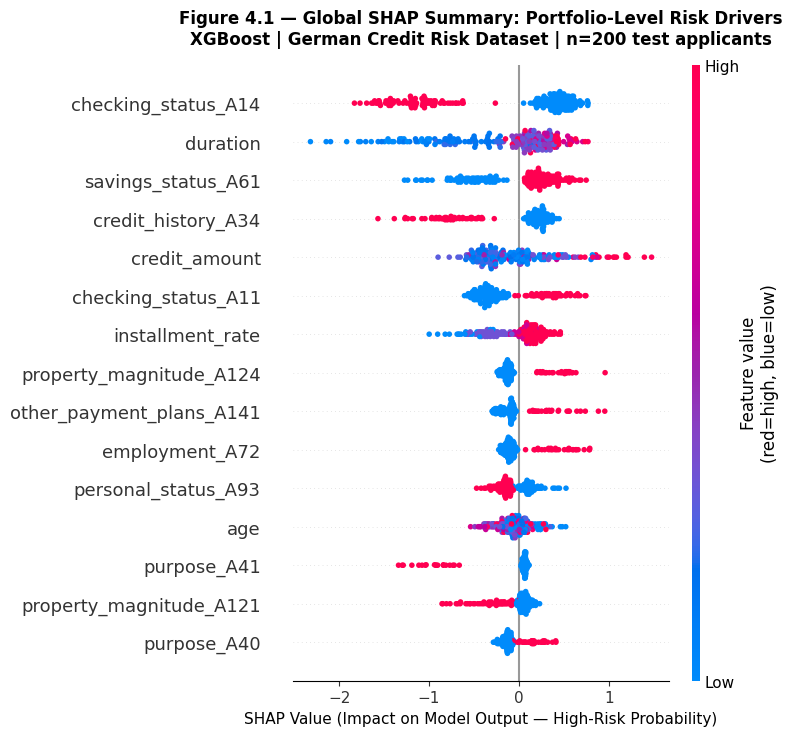


Top 10 Global Risk Drivers (Mean |SHAP| value):
                 Feature  Mean |SHAP|
     checking_status_A14     0.723229
                duration     0.519976
      savings_status_A61     0.388064
      credit_history_A34     0.377477
           credit_amount     0.356877
     checking_status_A11     0.355030
        installment_rate     0.238106
 property_magnitude_A124     0.183167
other_payment_plans_A141     0.168449
          employment_A72     0.162957


In [8]:
fig_global, ax_global = plt.subplots(figsize=(12, 8))


shap.summary_plot(
    shap_values,
    X_test_enc,
    feature_names=FEATURE_NAMES,
    max_display=15,
    plot_type='dot',
    color_bar_label='Feature value\n(red=high, blue=low)',
    show=False
)


plt.title('Figure 4.1 — Global SHAP Summary: Portfolio-Level Risk Drivers\n'
          'XGBoost | German Credit Risk Dataset | n=200 test applicants',
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('SHAP Value (Impact on Model Output — High-Risk Probability)',
           fontsize=11)
plt.tight_layout()
plt.savefig('fig4_1_global_shap_summary.png', dpi=200, bbox_inches='tight')
plt.show()


mean_abs_shap = pd.DataFrame({
    'Feature'        : FEATURE_NAMES,
    'Mean |SHAP|'    : np.abs(shap_df).mean().values
}).sort_values('Mean |SHAP|', ascending=False).head(10)


print('\nTop 10 Global Risk Drivers (Mean |SHAP| value):')
print(mean_abs_shap.to_string(index=False))


Explaining applicant at test index : 195
True label (1=High-Risk)           : 1
Model predicted probability         : 0.9839


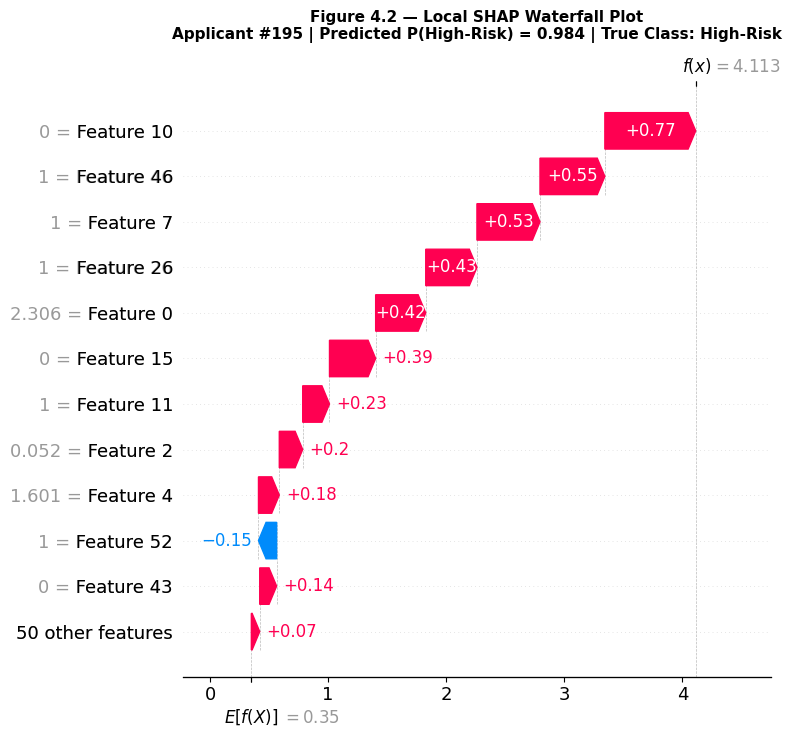


Top risk-increasing features for this applicant:
                Feature  Feature Value  SHAP Contribution
    checking_status_A14       0.000000           0.769460
property_magnitude_A124       1.000000           0.549373
    checking_status_A11       1.000000           0.533889
     savings_status_A61       1.000000           0.433669
               duration       2.305686           0.424120

Top risk-decreasing features for this applicant:
           Feature  Feature Value  SHAP Contribution
own_telephone_A192            0.0          -0.000290
savings_status_A63            0.0          -0.001161
          job_A171            0.0          -0.001225
       purpose_A45            0.0          -0.001379
credit_history_A31            0.0          -0.001826


In [9]:
high_risk_idx = int(np.argmax(y_pred_proba))


print(f'Explaining applicant at test index : {high_risk_idx}')
print(f'True label (1=High-Risk)           : {y_test.iloc[high_risk_idx]}')
print(f'Model predicted probability         : {y_pred_proba[high_risk_idx]:.4f}')


fig_local, ax_local = plt.subplots(figsize=(12, 7))


shap.plots.waterfall(
    shap_values[high_risk_idx],
    max_display=12,
    show=False
)


plt.title(
    f'Figure 4.2 — Local SHAP Waterfall Plot\n'
    f'Applicant #{high_risk_idx} | Predicted P(High-Risk) = {y_pred_proba[high_risk_idx]:.3f} | True Class: High-Risk',
    fontsize=11, fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig('fig4_2_local_shap_waterfall.png', dpi=200, bbox_inches='tight')
plt.show()


local_shap = pd.DataFrame({
    'Feature'          : FEATURE_NAMES,
    'Feature Value'    : X_test_enc[high_risk_idx],
    'SHAP Contribution': shap_values[high_risk_idx].values
}).sort_values('SHAP Contribution', ascending=False)


print('\nTop risk-increasing features for this applicant:')
print(local_shap[local_shap['SHAP Contribution'] > 0].head(5).to_string(index=False))
print('\nTop risk-decreasing features for this applicant:')
print(local_shap[local_shap['SHAP Contribution'] < 0].head(5).to_string(index=False))


  EVALUATION REPORT — XGBoost (Tuned) + SMOTE
  AUC-ROC Score            : 0.7802
  Average Precision (AP)   : 0.6512
  Brier Score (Calibration): 0.1737   (lower=better)
  Brier Skill Score        : 0.3052  (higher=better)

  Classification Report (threshold=0.5):
              precision    recall  f1-score   support

    Low-Risk     0.7961    0.8643    0.8288       140
   High-Risk     0.6042    0.4833    0.5370        60

    accuracy                         0.7500       200
   macro avg     0.7001    0.6738    0.6829       200
weighted avg     0.7385    0.7500    0.7412       200



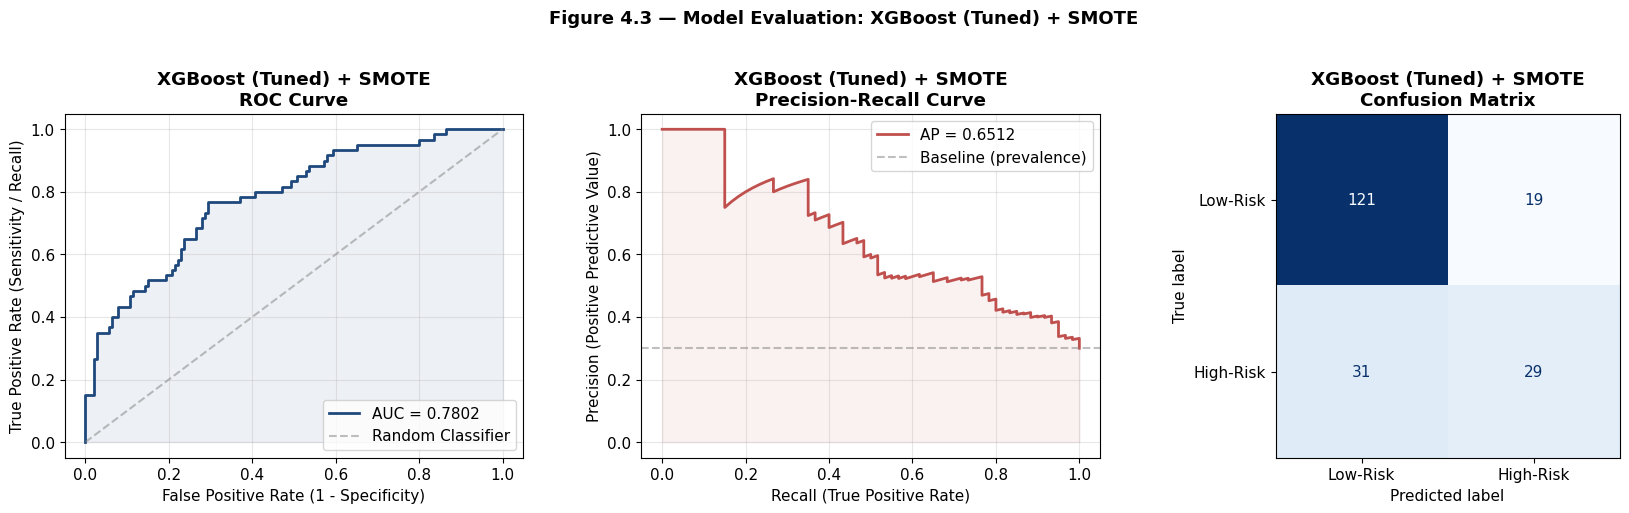

In [10]:
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    brier_score_loss, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)


def evaluate_risk_model(model_name, y_true, y_proba, y_pred, save_prefix='fig'):
    """
    Produces a full evaluation report for a binary risk classifier.


    Parameters
    ----------
    model_name  : str   — Label used in plot titles and printed output
    y_true      : array — True binary labels (0=Low-Risk, 1=High-Risk)
    y_proba     : array — Predicted probabilities for class 1 (High-Risk)
    y_pred      : array — Binary predicted labels (threshold=0.5)
    save_prefix : str   — Filename prefix for saved figures


    Returns
    -------
    dict containing AUC_ROC, Avg_Precision, Brier_Score
    """
    print('=' * 65)
    print(f'  EVALUATION REPORT — {model_name}')
    print('=' * 65)

    auc_roc = roc_auc_score(y_true, y_proba)
    fpr, tpr, roc_thresh = roc_curve(y_true, y_proba)


    precision, recall, pr_thresh = precision_recall_curve(y_true, y_proba)
    avg_precision = average_precision_score(y_true, y_proba)

    brier = brier_score_loss(y_true, y_proba)

    print(f'  AUC-ROC Score            : {auc_roc:.4f}')
    print(f'  Average Precision (AP)   : {avg_precision:.4f}')
    print(f'  Brier Score (Calibration): {brier:.4f}   (lower=better)')
    print(f'  Brier Skill Score        : {1 - brier/0.25:.4f}  (higher=better)')
    print()
    print('  Classification Report (threshold=0.5):')
    print(classification_report(y_true, y_pred,
                               target_names=['Low-Risk','High-Risk'],
                               digits=4))

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))


    axes[0].plot(fpr, tpr, lw=2, color='#1F497D',
                 label=f'AUC = {auc_roc:.4f}')
    axes[0].plot([0, 1], [0, 1], '--', color='grey', alpha=0.5,
                 label='Random Classifier')
    axes[0].fill_between(fpr, tpr, alpha=0.08, color='#1F497D')
    axes[0].set_title(f'{model_name}\nROC Curve', fontweight='bold')
    axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
    axes[0].set_ylabel('True Positive Rate (Sensitivity / Recall)')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)


    axes[1].plot(recall, precision, lw=2, color='#C0504D',
                 label=f'AP = {avg_precision:.4f}')
    axes[1].axhline(y=sum(y_true)/len(y_true), linestyle='--',
                    color='grey', alpha=0.5, label='Baseline (prevalence)')
    axes[1].fill_between(recall, precision, alpha=0.08, color='#C0504D')
    axes[1].set_title(f'{model_name}\nPrecision-Recall Curve', fontweight='bold')
    axes[1].set_xlabel('Recall (True Positive Rate)')
    axes[1].set_ylabel('Precision (Positive Predictive Value)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    cm_arr = confusion_matrix(y_true, y_pred)
    disp   = ConfusionMatrixDisplay(cm_arr,
               display_labels=['Low-Risk', 'High-Risk'])
    disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
    axes[2].set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')


    plt.suptitle(f'Figure 4.3 — Model Evaluation: {model_name}',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_evaluation.png', dpi=200, bbox_inches='tight')
    plt.show()


    return {'AUC_ROC': round(auc_roc, 4),
            'Avg_Precision': round(avg_precision, 4),
            'Brier_Score': round(brier, 4)}


xgb_metrics = evaluate_risk_model(
    model_name   = 'XGBoost (Tuned) + SMOTE',
    y_true       = y_test,
    y_proba      = y_pred_proba,
    y_pred       = y_pred,
    save_prefix  = 'fig4_3'
)


## Creating an Interactive Dashboard

In [11]:
# Install necessary libraries for Dash and Plotly
!pip install dash plotly

In [12]:
import dash
from dash import html, dcc
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, roc_auc_score, average_precision_score

app = dash.Dash(__name__)

mean_abs_shap = pd.DataFrame({
    'Feature'        : FEATURE_NAMES,
    'Mean |SHAP|'    : np.abs(shap_df).mean().values
}).sort_values('Mean |SHAP|', ascending=False).head(10)

fig_global_shap = px.bar(
    mean_abs_shap,
    x='Feature',
    y='Mean |SHAP|',
    title='<b>Global Risk Drivers (Mean |SHAP| value)</b>',
    labels={'Mean |SHAP|': 'Mean Absolute SHAP Value'},
    color='Mean |SHAP|',
    color_continuous_scale=px.colors.sequential.Plasma
)
fig_global_shap.update_layout(title_x=0.5)

explanation = shap_values[high_risk_idx]
base_value = explanation.base_values
shap_values_sample = explanation.values

df_local_shap = pd.DataFrame({
    'Feature': FEATURE_NAMES,
    'SHAP Value': shap_values_sample,
    'Feature Value': X_test_enc[high_risk_idx]
}).sort_values(by='SHAP Value', ascending=True)

df_local_shap = df_local_shap[df_local_shap['SHAP Value'] != 0]

display_count = 15 # Adjust as needed
df_local_shap_positive = df_local_shap[df_local_shap['SHAP Value'] > 0].tail(display_count // 2)
df_local_shap_negative = df_local_shap[df_local_shap['SHAP Value'] < 0].head(display_count // 2)
df_local_shap_display = pd.concat([df_local_shap_negative, df_local_shap_positive]).sort_values(by='SHAP Value', ascending=False)

fig_local_shap = go.Figure(go.Waterfall(
    name = "SHAP values",
    orientation = "h",
    measure = ["relative"] * len(df_local_shap_display) + ["total"],
    y = df_local_shap_display['Feature'].tolist() + ["Expected Value"],
    x = df_local_shap_display['SHAP Value'].tolist() + [base_value + np.sum(shap_values_sample)], # Final predicted value
    text = [f"Value: {val:.2f}" for val in df_local_shap_display['Feature Value'].tolist()] + [''],
    texttemplate = "%{text}",
    connector = {"line": {"color": "rgb(63, 63, 63)"}},
))

fig_local_shap.update_layout(
    title_text=f'<b>Local SHAP Waterfall Plot - Applicant #{high_risk_idx}</b><br>Predicted P(High-Risk) = {y_pred_proba[high_risk_idx]:.3f}',
    title_x=0.5,
    showlegend = False,
    height=600,
    waterfallgap = 0.2,
    yaxis_title='Feature',
    xaxis_title='SHAP Value (Impact on Model Output)'
)


fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_roc = roc_auc_score(y_test, y_pred_proba)
fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'AUC = {auc_roc:.4f}', line=dict(color='#1F497D', width=2)))
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random Classifier', line=dict(color='grey', dash='dash', width=1), opacity=0.5))
fig_roc.update_layout(title='<b>ROC Curve</b>', title_x=0.5, xaxis_title='False Positive Rate', yaxis_title='True Positive Rate', legend=dict(x=0.7, y=0.1, xanchor='left', yanchor='bottom'))

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)
fig_pr = go.Figure()
fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name=f'AP = {avg_precision:.4f}', line=dict(color='#C0504D', width=2)))
fig_pr.add_trace(go.Scatter(x=[0, 1], y=[sum(y_test)/len(y_test), sum(y_test)/len(y_test)], mode='lines', name='Baseline (prevalence)', line=dict(color='grey', dash='dash', width=1), opacity=0.5))
fig_pr.update_layout(title='<b>Precision-Recall Curve</b>', title_x=0.5, xaxis_title='Recall', yaxis_title='Precision', legend=dict(x=0.7, y=0.1, xanchor='left', yanchor='bottom'))

cm = confusion_matrix(y_test, y_pred)
cm_labels = ['Low-Risk', 'High-Risk']
fig_cm = px.imshow(cm, text_auto=True, color_continuous_scale='Blues',
                    labels=dict(x="Predicted", y="True", color="Count"),
                    x=cm_labels, y=cm_labels)
fig_cm.update_layout(title_text='<b>Confusion Matrix</b>', title_x=0.5, coloraxis_showscale=False)

app.layout = html.Div(children=[
    html.H1(children='Credit Risk Dashboard', style={'textAlign': 'center'}),

    html.Div(children='''
        Interactive visualizations for Credit Risk Model interpretability and performance evaluation.
    ''', style={'textAlign': 'center', 'marginBottom': '20px'}),

    html.Div([
        html.H2("Model Interpretability - SHAP Values", style={'textAlign': 'center', 'marginTop': '30px', 'marginBottom': '10px'}),
        dcc.Graph(id='global-shap-chart', figure=fig_global_shap),
        dcc.Graph(id='local-shap-waterfall', figure=fig_local_shap)
    ], style={'width': '98%', 'display': 'inline-block', 'padding': '10px'}),

    html.Div([
        html.H2("Model Performance Evaluation", style={'textAlign': 'center', 'marginTop': '30px', 'marginBottom': '10px'}),
        dcc.Graph(id='roc-curve', figure=fig_roc, style={'width': '33%', 'display': 'inline-block'}),
        dcc.Graph(id='pr-curve', figure=fig_pr, style={'width': '33%', 'display': 'inline-block'}),
        dcc.Graph(id='confusion-matrix', figure=fig_cm, style={'width': '33%', 'display': 'inline-block'})
    ], style={'display': 'flex', 'justifyContent': 'space-around', 'width': '98%', 'padding': '10px'})
])


In [13]:
!pip install pyngrok

In [14]:
from pyngrok import ngrok
import os

NGROK_AUTH_TOKEN = os.environ.get("NGROK_AUTH_TOKEN")

if NGROK_AUTH_TOKEN is None:
    try:
        from google.colab import userdata
        NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
    except Exception as e:
        print(f"Warning: Could not retrieve NGROK_AUTH_TOKEN from Colab userdata: {e}")
        print("Please ensure NGROK_AUTH_TOKEN is set in Colab secrets or hardcoded.")

if NGROK_AUTH_TOKEN:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    print("ngrok authtoken set.")
else:
    print("Error: NGROK_AUTH_TOKEN not found.")

ngrok authtoken set.


In [15]:
!pip install dash dash-bootstrap-components pyngrok --quiet
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve,
    average_precision_score, brier_score_loss,
    confusion_matrix, accuracy_score
)
import dash
from dash import dcc, html
import dash_bootstrap_components as dbc
import threading, os
from pyngrok import ngrok

fpr, tpr, _   = roc_curve(y_test, y_pred_proba)
roc_auc       = auc(fpr, tpr)
prec, rec, _  = precision_recall_curve(y_test, y_pred_proba)
ap_score      = average_precision_score(y_test, y_pred_proba)
brier         = brier_score_loss(y_test, y_pred_proba)
acc           = accuracy_score(y_test, y_pred)
cm            = confusion_matrix(y_test, y_pred)

mean_abs      = np.abs(shap_values.values).mean(axis=0)
top15_idx     = np.argsort(mean_abs)[::-1][:15]
top15_names   = [FEATURE_NAMES[i] for i in top15_idx]
top15_vals    = mean_abs[top15_idx]

hr_idx        = int(np.argmax(y_pred_proba))
hr_prob       = y_pred_proba[hr_idx]
hr_shap       = shap_values[hr_idx].values
hr_base       = shap_values[hr_idx].base_values
top12_local   = np.argsort(np.abs(hr_shap))[::-1][:12]
wf_names      = [FEATURE_NAMES[i] for i in top12_local]
wf_vals       = hr_shap[top12_local]
wf_feats      = X_test_enc[hr_idx][top12_local]


C_TEAL   = "#2EC4B6"
C_RED    = "#E63946"
C_NAVY   = "#1D3557"
C_GOLD   = "#F4A261"
C_GREY   = "#6B7280"
C_BG     = "#F8FAFC"
C_CARD   = "#FFFFFF"

FONT = dict(family="Inter, Helvetica, Arial, sans-serif", color="#1D3557")

def base_layout(title=""):
    return dict(
        title=dict(text=title, font=dict(size=14, color=C_NAVY, family="Inter"), x=0.03),
        paper_bgcolor=C_CARD,
        plot_bgcolor=C_BG,
        font=FONT,
        margin=dict(l=50, r=30, t=50, b=45),
        legend=dict(bgcolor="rgba(0,0,0,0)", font=dict(size=11)),
    )

fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(
    x=fpr, y=tpr, mode="lines", name=f"XGBoost (AUC = {roc_auc:.4f})",
    line=dict(color=C_TEAL, width=2.5)
))
fig_roc.add_trace(go.Scatter(
    x=[0,1], y=[0,1], mode="lines", name="Random classifier",
    line=dict(color=C_GREY, width=1.5, dash="dash")
))
fig_roc.update_layout(
    **base_layout("ROC Curve"),
    xaxis=dict(title="False Positive Rate", gridcolor="#E5E7EB"),
    yaxis=dict(title="True Positive Rate", gridcolor="#E5E7EB"),
)

fig_pr = go.Figure()
fig_pr.add_trace(go.Scatter(
    x=rec, y=prec, mode="lines", name=f"XGBoost (AP = {ap_score:.4f})",
    line=dict(color=C_GOLD, width=2.5), fill="tozeroy",
    fillcolor="rgba(244,162,97,0.12)"
))
fig_pr.update_layout(
    **base_layout("Precision-Recall Curve"),
    xaxis=dict(title="Recall", gridcolor="#E5E7EB"),
    yaxis=dict(title="Precision", gridcolor="#E5E7EB"),
)

labels = ["Low-Risk", "High-Risk"]
fig_cm = ff.create_annotated_heatmap(
    z=cm[::-1],
    x=labels, y=labels[::-1],
    colorscale=[[0,"#EFF6FF"],[0.5,"#93C5FD"],[1,C_NAVY]],
    showscale=False,
    font_colors=["black","white"]
)
fig_cm.update_layout(
    **base_layout("Confusion Matrix"),
    xaxis=dict(title="Predicted", side="bottom"),
    yaxis=dict(title="Actual"),
)
colours_bar = [C_TEAL if i < 5 else C_GOLD if i < 10 else C_GREY
               for i in range(len(top15_names))]
fig_shap_global = go.Figure(go.Bar(
    x=top15_vals[::-1],
    y=top15_names[::-1],
    orientation="h",
    marker_color=colours_bar[::-1],
    text=[f"{v:.4f}" for v in top15_vals[::-1]],
    textposition="outside",
    textfont=dict(size=10),
))
fig_shap_global.update_layout(
    **base_layout("Global SHAP Feature Importance (Mean |SHAP|)"),
    xaxis=dict(title="Mean |SHAP Value|", gridcolor="#E5E7EB"),
    yaxis=dict(tickfont=dict(size=10.5)),
    height=480,
)

wf_colours = [C_RED if v > 0 else C_TEAL for v in wf_vals]
# Sort ascending for waterfall
order      = np.argsort(wf_vals)
wf_names_s = [wf_names[i] for i in order]
wf_vals_s  = wf_vals[order]
wf_col_s   = [C_RED if v > 0 else C_TEAL for v in wf_vals_s]

fig_shap_local = go.Figure(go.Bar(
    x=wf_vals_s,
    y=[f"{n}  (val={wf_feats[order[i]]:.2f})" for i, n in enumerate(wf_names_s)],
    orientation="h",
    marker_color=wf_col_s,
    text=[f"{v:+.3f}" for v in wf_vals_s],
    textposition="outside",
    textfont=dict(size=10),
))
fig_shap_local.add_vline(x=0, line_width=1.5, line_color=C_NAVY)
fig_shap_local.update_layout(
    **base_layout(
        f"Local SHAP Waterfall — Applicant #{hr_idx} "
        f"| P(High-Risk) = {hr_prob:.3f} | True: {'High-Risk' if y_test.iloc[hr_idx]==1 else 'Low-Risk'}"
    ),
    xaxis=dict(title="SHAP Contribution", gridcolor="#E5E7EB"),
    yaxis=dict(tickfont=dict(size=10)),
    height=420,
)

def kpi_card(label, value, colour):
    return dbc.Col(
        dbc.Card([
            dbc.CardBody([
                html.H4(value, style={"color": colour, "fontWeight":"700",
                                      "margin":"0","fontSize":"26px"}),
                html.P(label, style={"color": C_GREY, "fontSize":"12px",
                                     "margin":"0","marginTop":"4px"}),
            ], style={"textAlign":"center","padding":"18px 10px"}),
        ], style={"border":"none","borderRadius":"12px",
                  "boxShadow":"0 2px 12px rgba(0,0,0,0.08)",
                  "background": C_CARD}),
        xs=6, md=3, className="mb-3"
    )

app = dash.Dash(
    __name__,
    external_stylesheets=[
        dbc.themes.BOOTSTRAP,
        "https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700&display=swap"
    ],
    title="XAI Credit Risk Dashboard"
)

HEADER_STYLE = {
    "background": f"linear-gradient(135deg, {C_NAVY} 0%, #457B9D 100%)",
    "padding": "28px 40px 24px",
    "marginBottom": "28px",
    "boxShadow": "0 4px 20px rgba(0,0,0,0.15)"
}

SECTION_STYLE = {
    "background": C_CARD,
    "borderRadius": "14px",
    "padding": "24px",
    "marginBottom": "24px",
    "boxShadow": "0 2px 12px rgba(0,0,0,0.07)"
}

def section_title(text):
    return html.H5(text, style={
        "color": C_NAVY, "fontWeight": "700",
        "borderLeft": f"4px solid {C_TEAL}",
        "paddingLeft": "12px", "marginBottom": "18px"
    })

app.layout = dbc.Container([

    html.Div([
        dbc.Row([
            dbc.Col([
                html.H2("XAI Credit Risk Dashboard",
                        style={"color":"white","fontWeight":"700",
                               "margin":"0","fontFamily":"Inter"}),
                html.P("XGBoost + SMOTE + Optuna + SHAP  ·  German Credit Dataset (n=1,000)",
                       style={"color":"rgba(255,255,255,0.75)","margin":"4px 0 0",
                              "fontSize":"13px"}),
            ], md=8),
            dbc.Col([
                html.Div([
                    html.Span("● LIVE", style={"color":"#4ADE80","fontWeight":"700",
                                               "fontSize":"13px"}),
                    html.Span("  Model Ready", style={"color":"rgba(255,255,255,0.7)",
                                                       "fontSize":"13px"}),
                ], style={"textAlign":"right","paddingTop":"8px"}),
            ], md=4),
        ])
    ], style=HEADER_STYLE),

    dbc.Container([

        html.Div([
            section_title("Model Performance Summary"),
            dbc.Row([
                kpi_card("AUC-ROC",        f"{roc_auc:.4f}", C_TEAL),
                kpi_card("Average Precision", f"{ap_score:.4f}", C_GOLD),
                kpi_card("Brier Score",    f"{brier:.4f}",    "#10B981"),
                kpi_card("Accuracy",       f"{acc*100:.1f}%", C_RED),
            ])
        ], style=SECTION_STYLE),

        html.Div([
            section_title("Evaluation Curves & Confusion Matrix"),
            dbc.Row([
                dbc.Col(dcc.Graph(figure=fig_roc,  config={"displayModeBar":False},
                                  style={"height":"320px"}), md=4),
                dbc.Col(dcc.Graph(figure=fig_pr,   config={"displayModeBar":False},
                                  style={"height":"320px"}), md=4),
                dbc.Col(dcc.Graph(figure=fig_cm,   config={"displayModeBar":False},
                                  style={"height":"320px"}), md=4),
            ])
        ], style=SECTION_STYLE),

        html.Div([
            section_title("Global SHAP Feature Importance (Top 15 Features)"),
            dbc.Row([
                dbc.Col(dcc.Graph(figure=fig_shap_global,
                                  config={"displayModeBar":False},
                                  style={"height":"500px"}), md=8),
                dbc.Col([
                    html.H6("Top 5 Risk Drivers",
                            style={"color":C_NAVY,"fontWeight":"600",
                                   "marginBottom":"12px"}),
                    *[
                        html.Div([
                            html.Span(f"#{i+1}  {top15_names[i]}",
                                      style={"fontWeight":"600","color":C_NAVY,
                                             "fontSize":"12px"}),
                            html.Div(
                                style={
                                    "height":"8px","borderRadius":"4px","marginTop":"4px",
                                    "marginBottom":"10px","background":C_TEAL,
                                    "width": f"{int(top15_vals[i]/top15_vals[0]*100)}%"
                                }
                            ),
                            html.Small(f"Mean |SHAP| = {top15_vals[i]:.4f}",
                                       style={"color":C_GREY}),
                        ]) for i in range(5)
                    ],
                    html.Hr(style={"borderColor":"#E5E7EB","margin":"16px 0"}),
                    html.Small(
                        "Teal = top 5  ·  Gold = 6–10  ·  Grey = 11–15",
                        style={"color":C_GREY}
                    ),
                ], md=4, style={"paddingTop":"20px"}),
            ])
        ], style=SECTION_STYLE),

        html.Div([
            section_title("Local SHAP Explanation — Highest-Risk Applicant"),
            dbc.Row([
                dbc.Col([
                    dbc.Alert([
                        html.B(f"Applicant #{hr_idx}"),
                        html.Span(f"  ·  Predicted P(High-Risk) = "),
                        html.B(f"{hr_prob:.3f}", style={"color":C_RED}),
                        html.Span(f"  ·  True label: "),
                        html.B("High-Risk" if y_test.iloc[hr_idx]==1 else "Low-Risk"),
                        html.Span(f"  ·  Base value: {float(hr_base):.3f}"),
                    ], color="light",
                       style={"border":f"1px solid {C_TEAL}","borderRadius":"8px",
                              "fontSize":"13px","marginBottom":"14px"}),
                    dcc.Graph(figure=fig_shap_local,
                              config={"displayModeBar":False},
                              style={"height":"450px"}),
                    html.Small(
                        "🟥 Red bars push prediction toward High-Risk  ·  "
                        "🟦 Teal bars push prediction toward Low-Risk",
                        style={"color":C_GREY,"display":"block","marginTop":"8px"}
                    )
                ], md=12),
            ])
        ], style=SECTION_STYLE),

        html.Div(
            html.Small(
                "XAI Credit Risk Prediction System  ·  German Credit (Statlog) Dataset  ·  "
                "XGBoost + SMOTE + Optuna + SHAP  ·  University of Westminster",
                style={"color":C_GREY}
            ),
            style={"textAlign":"center","padding":"16px 0 24px"}
        ),

    ], fluid=True),

], fluid=True, style={"background":"#F1F5F9","minHeight":"100vh",
                       "fontFamily":"Inter, Helvetica, Arial, sans-serif",
                       "padding":"0"})

port = 8050

try:
    from google.colab import userdata
    token = userdata.get('NGROK_AUTH_TOKEN')
except Exception:
    token = os.environ.get("NGROK_AUTH_TOKEN")

if token:
    ngrok.set_auth_token(token)
    print("✓ ngrok token set")
else:
    print(" No ngrok token found — tunnel may not work on free tier")

ngrok.kill()

# Open tunnel
public_url = ngrok.connect(port)
print(f"\n{'='*55}")
print(f"    Dashboard live at: {public_url}")
print(f"{'='*55}\n")

app.run(port=port, debug=False, use_reloader=False)

✓ ngrok token set

    Dashboard live at: NgrokTunnel: "https://mushiness-neurology-ditch.ngrok-free.dev" -> "http://localhost:8050"

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [06/May/2026 07:10:21] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/May/2026 07:10:22] "GET /_dash-dependencies HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/May/2026 07:10:22] "GET /_dash-layout HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/May/2026 07:10:22] "GET /_favicon.ico?v=4.1.0 HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/May/2026 07:10:23] "GET /_dash-component-suites/dash/dcc/async-graph.js HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [06/May/2026 07:10:23] "GET /_dash-component-suites/plotly/package_data/plotly.min.js HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [06/May/2026 07:18:17] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/May/2026 07:18:18] "GET /_dash-dependencies HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/Ma